In [1]:
from deepface import DeepFace
import time
import os
import mozuma
%load_ext autoreload
import cv2
%autoreload 2
import matplotlib.pyplot as plt


2025-04-22 13:18:33.921290: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-22 13:18:39.103119: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-22 13:18:40.078307: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/slurm/current/lib::
2025-04-22 13:18:40.078333: I tensorflow/stream_executor/cuda/cudart_st

In [6]:
start = time.perf_counter()
import shutil

num = 0
for path in os.listdir("data/pubfig83/Nicole Richie/"):
    total_path = "data/pubfig83/Nicole Richie/" + path
    try:
        emb = DeepFace.represent(total_path)
        print(emb)
        break
    except:
        print(num, "Face not found")
    num += 1
end = time.perf_counter()
print("Faces took", end - start, "seconds")
print("Average time:", (end - start) / num, "sec.")

0 Face not found
[{'embedding': [0.0, 0.0, 0.013487322930763683, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12312239031468297, 0.0, 0.0, 0.0, 0.0, 0.013868773762704284, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0037894928002269374, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0077531827403972565, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02016837161514664, 0.0, 0.0, 0.0, 0.0, 0.018687955733295892, 0.0289375110000265, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.017607248313233917, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0017633854468013298, 0.0, 0.0, 0.012392332157883929, 0.0, 0.0, 0.008866709157559681, 0.0, 0.021705767162240278, 0.0, 0.0, 0.0, 0.0, 0.015889774551620946, 0.027542315501234958, 0.0, 0.016056667599238402, 0.07445983494989308, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.017818854867406222, 0.031412038296522206, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0113

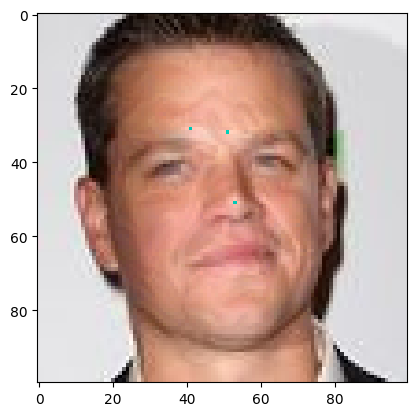

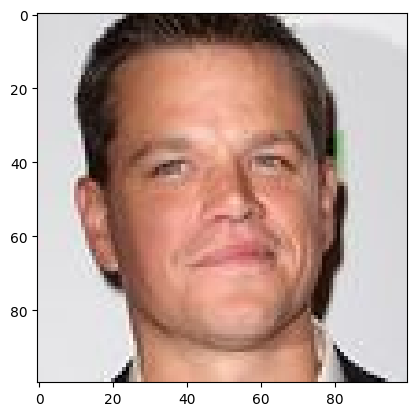

In [11]:
path = "Matt Damon_237"
im = cv2.imread("data/pubfig_cloaked/" + path + ".png")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.show()
im2 = cv2.imread("data/pubfig_flat/" + path + ".jpg")
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)
plt.imshow(im2)
plt.show()


In [3]:
import shutil
for name in os.listdir("data/pubfig83/"):
    print(name)
    for path in os.listdir("data/pubfig83/" + name + "/"):
        shutil.copyfile("data/pubfig83/" + name + "/" + path, "data/pubfig_flat/" + name + "_" + path)

Morgan Freeman
Will Smith
Dustin Hoffman
Leonardo DiCaprio
Matt Damon
Renee Zellweger
Colin Powell
Jessica Alba
Mickey Rourke
Eva Mendes
Cameron Diaz
Steve Carell
Brad Pitt
Drew Barrymore
Robert Gates
Uma Thurman
Angelina Jolie
Charlize Theron
Daniel Radcliffe
Hugh Jackman
Shahrukh Khan
Viggo Mortensen
David Beckham
Lindsay Lohan
Julia Stiles
Martha Stewart
Jennifer Lopez
Jack Nicholson
Tom Cruise
Mariah Carey
David Duchovny
Halle Berry
Ashton Kutcher
Silvio Berlusconi
Michael Bloomberg
Orlando Bloom
Meryl Streep
Denise Richards
Sania Mirza
Julia Roberts
Ben Affleck
Christina Ricci
Stephen Colbert
Shakira
Harrison Ford
Zac Efron
Kiefer Sutherland
Kate Winslet
Claudia Schiffer
Jennifer Aniston
Jessica Simpson
Kate Moss
Hugh Laurie
Daniel Craig
Nicole Richie
Adam Sandler
Faith Hill
Scarlett Johansson
Anna Kournikova
Clive Owen
Cristiano Ronaldo
Colin Farrell
John Travolta
Joaquin Phoenix
Miley Cyrus
Alec Baldwin
Beyonce Knowles
Reese Witherspoon
Sharon Stone
Jennifer Love Hewitt
Nicole K

In [8]:
from mozuma.models.arcface.pretrained import torch_arcface_insightface
from facenet_pytorch import MTCNN
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms as trans


In [9]:
device = torch.device("cuda")
arcface = torch_arcface_insightface(device=device)
mtcnn = MTCNN(image_size=112) #arcface was 112x112 images
arcface.load_state_dict(torch.load("model_checkpoints/arcface.pth"))
arcface.eval()
mtcnn.eval()

MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=48)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv3): Conv2d(48, 64,

In [130]:
def get_out(path):
    mean = torch.Tensor([0.485, 0.456, 0.406])
    std = torch.Tensor([0.229, 0.224, 0.225])
    test_transform = trans.Compose([
                    trans.Normalize(mean, std)
                ])
    inv_transform = trans.Compose([
                    trans.Normalize((-mean / std), 1.0 / std)
    ])
    
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(im)
    
    print("box:", boxes)

    xmin = int(boxes[0][0])
    xmax = int(boxes[0][2])
    ymin = int(boxes[0][1])
    ymax = int(boxes[0][3])
    
    cv2.rectangle(im, (xmin, ymin), (xmax, ymax), (255, 0, 0), 1)
    plt.imshow(im)
    plt.title("Original")
    plt.show()
    
    # Apply the boxes and resize the crop
    crop = im[ymin:ymax, xmin:xmax :]
    orig_crop_shape = crop.shape
    crop = cv2.resize(crop, (112, 112), interpolation=cv2.INTER_LINEAR)
    crop = np.transpose(crop, (2, 0, 1))
    crop = torch.Tensor(crop)
    
    # Get a separate version to visualize and show it
    crop_show = (np.transpose(crop.clone(), (1, 2, 0)))
    plt.imshow(crop_show / 255.0)
    plt.title("Crop")
    plt.show()
    
    # Normalize it and get it to the right batch size for arcface
    print("crop has shape", crop.size())
    crop = test_transform(crop)
    crop = crop.repeat((2, 1, 1, 1))
    crop.requires_grad = True
    print("Right before arcface crop has shape ", crop.size())
    out2 = arcface(crop)
    
    # Now see if we can reconstruct the face
    crop = inv_transform(crop)
    crop = np.transpose(crop[0].detach().cpu().numpy(), (1, 2, 0))
    crop_rescaled = cv2.resize(crop, (xmax - xmin, ymax - ymin), interpolation=cv2.INTER_LINEAR)
    print("rescaled crop has shape", crop_rescaled.shape)
    print("original image has shape", im.shape)
    print("xrange:", xmax - xmin)
    im[ymin:ymax, xmin:xmax, :] = crop_rescaled
    plt.imshow(im)
    plt.title("Repatched")
    plt.show()
    
    return out2

box: [[25.846988677978516 15.727347373962402 77.20774841308594
  82.36663818359375]]


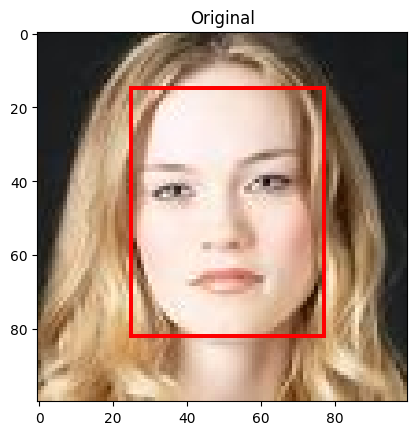

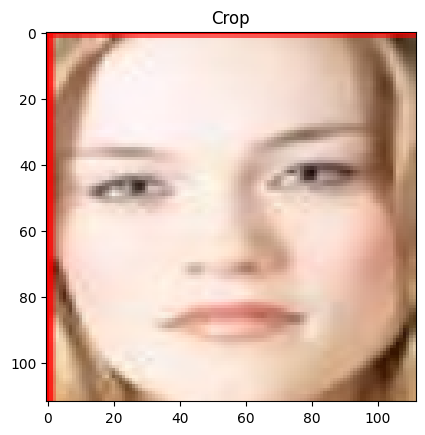

crop has shape torch.Size([3, 112, 112])
Right before arcface crop has shape  torch.Size([2, 3, 112, 112])
rescaled crop has shape (67, 52, 3)
original image has shape (100, 100, 3)
xrange: 52


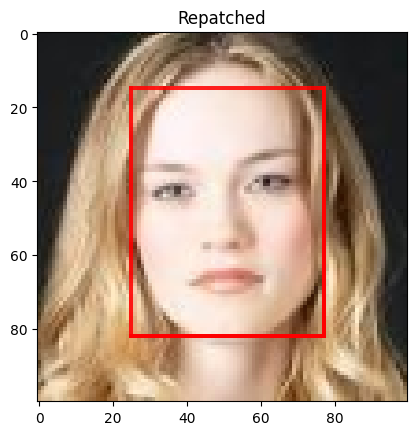

box: [[25.69470977783203 18.188268661499023 78.00242614746094
  85.03868865966797]]


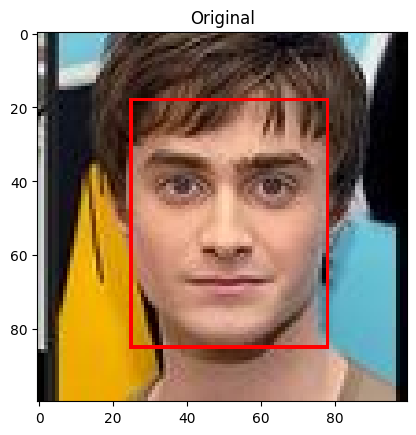

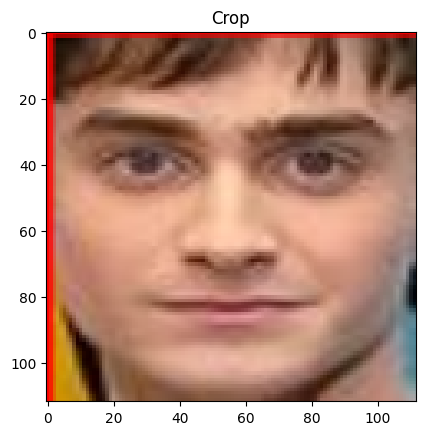

crop has shape torch.Size([3, 112, 112])
Right before arcface crop has shape  torch.Size([2, 3, 112, 112])
rescaled crop has shape (67, 53, 3)
original image has shape (100, 100, 3)
xrange: 53


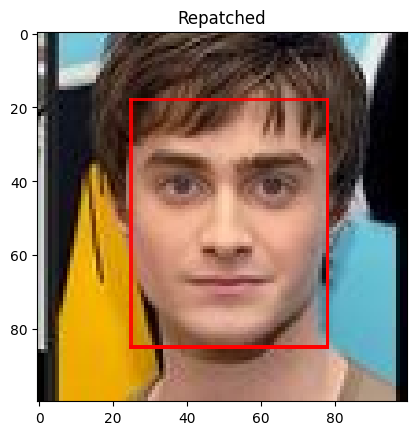

tensor(0.3468, grad_fn=<LinalgVectorNormBackward0>)


In [131]:
save1 = get_out("data/pubfig_flat/Julia Stiles_100.jpg")[0][:] 
save2 = get_out("data/pubfig_flat/Daniel Radcliffe_100.jpg")[0][:]
# print(save1)
# print(save2)
print(torch.linalg.vector_norm(save1 - save2, ord=2))

In [5]:
print("Crop requires grad:", crop.requires_grad)
loss = torch.sum(out)
print("Loss:", loss)
loss.backward()
print("Grad:", crop.grad)

Crop requires grad: True
Loss: tensor(-0.0650, grad_fn=<SumBackward0>)
Grad: tensor([[[[-7.2784e-05,  3.2593e-05,  5.7684e-06,  ..., -9.5910e-06,
           -8.1798e-06, -3.0741e-06],
          [-4.3783e-05,  1.1826e-04,  1.9427e-04,  ..., -2.4816e-05,
           -1.3553e-05, -2.3412e-06],
          [-4.5600e-05,  5.6732e-05,  1.6423e-04,  ..., -3.0403e-05,
           -5.1965e-06,  2.3856e-07],
          ...,
          [ 2.8837e-05,  6.2918e-05, -3.4197e-05,  ..., -2.5009e-04,
            9.1311e-05,  3.2781e-05],
          [ 1.5553e-05,  3.0784e-05, -5.7402e-05,  ..., -9.6622e-05,
           -3.0813e-05, -7.0605e-06],
          [ 2.7829e-05,  2.0388e-05, -1.8038e-05,  ..., -4.2040e-05,
           -6.4268e-06,  8.4778e-06]],

         [[-2.6049e-04, -8.0614e-05,  1.0182e-04,  ..., -2.6604e-05,
           -3.3371e-05, -1.8577e-05],
          [-1.8448e-04,  1.2855e-04,  5.1321e-04,  ..., -6.0044e-05,
           -5.2221e-05, -1.5203e-05],
          [-1.2615e-04,  6.6383e-05,  4.3234e-04, 

None
